# Sensitiviy analysis on site selection

In [2]:
%load_ext autoreload
%autoreload 2

import os
import seaborn as sns
import x4c  # https://ncar.github.io/x4c/
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
print(x4c.__version__)
os.chdir('/glade/work/fengzhu/Projects/paper-MCO_iCESM/notebooks')
import BayesianEst as be

x4c.set_style('journal_spines', font_scale=1.2)

2026.5.26


## Load Data

In [3]:
df_iCESM = pd.read_csv('../data/df_iCESM.csv', index_col=0)
df_sites = pd.read_csv('../data/df_d18Ob_sites_MCO.csv', index_col=0)

mdl_TEMP = {}
mdl_d18Osw = {}
for tag in ['1.5x', '3x']:
    mdl_TEMP[tag] = float(df_iCESM.loc[tag, 'BWT'])
    mdl_d18Osw[tag] = float(df_iCESM.loc[tag, 'BWd18Osw'])

## Site-selection sensitivity: random subsets without replacement at varying k

In [4]:
all_sites = list(df_sites.index)

def psm_for_sites(site_list):
    """Bayesian PSM applied to an arbitrary subset of sites.
    """
    m = df_sites.loc[df_sites.index.isin(site_list)]
    mu = float(m['mean'].mean())
    sig_t = float(np.sqrt(np.sum(m['std'].values**2)) / len(m))
    sig_s = float(np.std(m['mean'].values, ddof=1) / np.sqrt(len(m))) if len(m) > 1 else 0.0
    sigma = float(np.sqrt(sig_t**2 + sig_s**2))
    res = be.get_est(df_iCESM, mdl_TEMP, mdl_d18Osw, mu, sigma,
                   d18Osw_mu=-0.55, d18Osw_sigma=0.1,
                   DpH_mu=-0.2, DpH_sigma=0.05)
    df_CO2pdf  = res['df_CO2pdf']
    idx = np.argmax(df_CO2pdf['density'])
    dGMST = df_CO2pdf.iloc[idx]['dGMST']

    return dGMST

In [5]:
rng = np.random.default_rng(0)
k_values = [10, 12, 14, 16, 18, 20]
n_iter = 100

sub_rows = []
for k in k_values:
    iters = 1 if k == len(all_sites) else n_iter
    for _ in range(iters):
        sel = rng.choice(all_sites, size=k, replace=False)
        mle = psm_for_sites(list(sel))
        sub_rows.append({'k': k, 'dGMST_mle': mle})
df_subset = pd.DataFrame(sub_rows)
mle0 = psm_for_sites(all_sites)
print('random-subset (no replacement) MLE distribution by k:')
print(df_subset.groupby('k')['dGMST_mle'].agg(median='median', mean='mean', std='std', min='min', max='max').round(3))
print(f'\nbaseline ({len(all_sites)} sites) MLE = {mle0:.3f} degC')

random-subset (no replacement) MLE distribution by k:
    median   mean    std    min    max
k                                     
10   7.507  7.512  0.252  6.889  8.126
12   7.495  7.487  0.210  6.993  7.852
14   7.523  7.508  0.171  7.122  7.909
16   7.515  7.497  0.144  7.065  7.804
18   7.543  7.535  0.118  7.202  7.764
20   7.511  7.504  0.081  7.298  7.716

baseline (23 sites) MLE = 7.507 degC


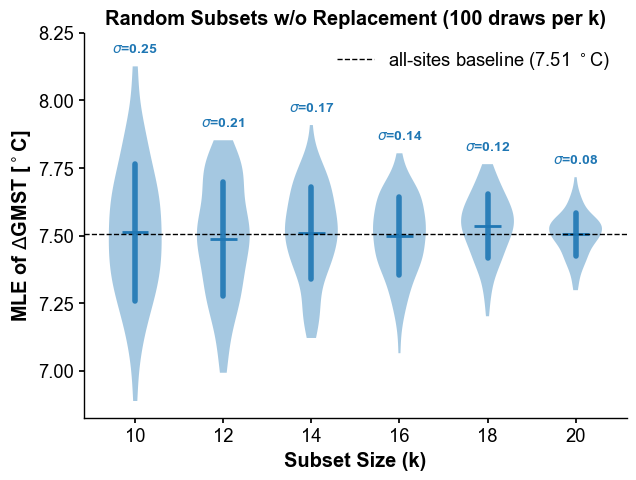

Figure saved at: "../figs/SIFig.05.pdf"


In [6]:
x4c.set_style('journal_nogrid', font_scale=1.2)
fig, ax = plt.subplots(figsize=(7, 5))
data = [df_subset.loc[df_subset['k'] == k, 'dGMST_mle'].values for k in k_values]
means = [float(np.mean(d)) for d in data]
stds  = [float(np.std(d, ddof=1)) for d in data]

parts = ax.violinplot(data, positions=k_values, widths=1.2,
                      showmeans=True, showmedians=False, showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor('tab:blue'); pc.set_alpha(0.4)

# highlight per-k +/- 1 sigma as a thick vertical bar over each violin
for k, m, s in zip(k_values, means, stds):
    ax.vlines(k, m - s, m + s, color='tab:blue', lw=4, alpha=0.9,
              zorder=5, capstyle='round')

ax.axhline(mle0, ls='--', color='k', lw=1,
           label=f'all-sites baseline ({mle0:.2f} $^\\circ$C)')

# annotate per-k std above each violin
for k, d, s in zip(k_values, data, stds):
    ax.text(k, d.max() + 0.04, f'$\\sigma$={s:.2f}',
            ha='center', va='bottom', fontsize=10,
            color='tab:blue', fontweight='bold')

ax.set_xticks(k_values); ax.set_xticklabels(k_values)
ax.set_xlabel('Subset Size (k)', weight='bold')
ax.set_ylabel(r'MLE of $\Delta$GMST [$^\circ$C]', weight='bold')
ax.set_title(f'Random Subsets w/o Replacement ({n_iter} draws per k)', weight='bold')
ax.legend(loc='upper right')
ax.set_yticks([7.0, 7.25, 7.5, 7.75, 8.0, 8.25])
x4c.showfig(fig)
x4c.savefig(fig, '../figs/SIFig.05.pdf')